# NYC Taxi Trip Duration Analysis

This notebook contains analysis on the NYC Taxi Trip Duration dataset from Kaggle (https://www.kaggle.com/competitions/nyc-taxi-trip-duration/data). This is split in three sections: Exploratory Data Analysis (EDA), Feature Engineering, and Model training and evaluation.

**AI Tools Disclosure**
* We used Google + Gemini to gather factual information such as NYC-related documents, and Haversine distance documentation/usage. 
* We also used Claude as a coding assistant.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle
from matplotlib.colors import LinearSegmentedColormap

In [2]:
df_taxi = pd.read_csv('nyc-taxi-trip-duration/train.zip')
print(f"{df_taxi.shape[0]} rows, {df_taxi.shape[1]} columns")
df_taxi.head()

1458644 rows, 11 columns


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


# Exploratory Data Analysis

This section contains data-quality checks, distributions, and data cleaning processes by implementing data filters.

### Data quality check

In [3]:
# Check for nulls
print('Number of nulls per column:')
print(df_taxi.isnull().sum())
print('\n')

# Check for duplicates
print('Number of duplicate trips by id')
print(df_taxi['id'].duplicated().sum())

Number of nulls per column:
id                    0
vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
dtype: int64


Number of duplicate trips by id
0


The dataset has no null values and duplicate trip Ids. This was expected because the authors of the datset explicitly mentioned the data was pre-cleaned for the purposes of the Kaggle competition.

In [4]:
# Checking data types
df_taxi.info()

<class 'pandas.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  str    
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  str    
 3   dropoff_datetime    1458644 non-null  str    
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  str    
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), str(4)
memory usage: 122.4 MB


It can be observed that the `pickup_datetime` and `dropoff_datetime` columns are in string format. We should convert this to the appropriate datetime format later. All other columns look normal.

In [5]:
# Sanity check for trip duration values
print(df_taxi['trip_duration'].describe())

df_taxi['pickup_datetime'] = pd.to_datetime(df_taxi['pickup_datetime'])
df_taxi['dropoff_datetime'] = pd.to_datetime(df_taxi['dropoff_datetime'])
df_taxi['trip_duration_calculated'] = (df_taxi['dropoff_datetime'] - df_taxi['pickup_datetime']).dt.total_seconds()

df_taxi['is_correct_duration'] = (df_taxi['trip_duration'] == df_taxi['trip_duration_calculated'])
incorrect_duration_count = (df_taxi['is_correct_duration'] == False).sum()
print('\n')
print(f'Number of incorrect trip duration: {incorrect_duration_count}')
print(f'Percentage of incorrect trip duration: {incorrect_duration_count/len(df_taxi['is_correct_duration'])}%')


count    1.458644e+06
mean     9.594923e+02
std      5.237432e+03
min      1.000000e+00
25%      3.970000e+02
50%      6.620000e+02
75%      1.075000e+03
max      3.526282e+06
Name: trip_duration, dtype: float64


Number of incorrect trip duration: 0
Percentage of incorrect trip duration: 0.0%


The purpose of the above cell is to manually calculate the trip duration using `dropoff_datetime` - `pickup_datetime` . We then compared the calculated trip duration with the provided one. We cross checked the two values and there were no mismatch. All provided trip duration values are correct and accurate.

### Distributions

Haversine formula was used to calculate distance between two points on the Earth using latitude and longitude. It requires the latitudes and longitudes to be in radians. We must use the Haversine formula to take into account the curvature of the earth. In this study, we are assuming that the pickup and dropoff location are not coplanar i.e. they are not contained in a single flat surface.

We note however that the Haversine distance does not describe the route taken. The exact route/distance traveled is not available in the dataset. It is our judgement that the Haversine distance is the best distance that we can make out of the dataset.

We obtained formula from https://www.movable-type.co.uk/scripts/latlong.html

In [6]:
EARTH_RADIUS_KM = 6371.0

# Haversine formula to calculate distance between two points on the Earth using latitude and longitude
# We obtained formula from https://www.movable-type.co.uk/scripts/latlong.html
def haversine_distance(lat1, lon1, lat2, lon2):
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = np.sin(dlat / 2) ** 2 + (np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2)
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    distance_km = EARTH_RADIUS_KM * c
    return distance_km

df_taxi['haversine_distance'] = haversine_distance(
    df_taxi['pickup_latitude'], 
    df_taxi['pickup_longitude'], 
    df_taxi['dropoff_latitude'], 
    df_taxi['dropoff_longitude'])

print(df_taxi[['haversine_distance', 'trip_duration', 'passenger_count']].agg(['mean', 'median', 'std', 'min', 'max']))
print('\n')
print(f'Longest trip duration in hours: {df_taxi['trip_duration'].max() / 3600:.2f}')


        haversine_distance  trip_duration  passenger_count
mean              3.440864   9.594923e+02         1.664530
median            2.093717   6.620000e+02         1.000000
std               4.296538   5.237432e+03         1.314242
min               0.000000   1.000000e+00         0.000000
max            1240.908677   3.526282e+06         9.000000


Longest trip duration in hours: 979.52


The longest trip took approximately 979 hours. That is roughly equivalent to 40 days! This looks like an outlier and we have to address this. There was also a max Haversine distance of 1240 km. This is a very big value compared to the mean, median, and standard deviation. It's also possible that one of the pickup or dropoff locations lie outside NYC.

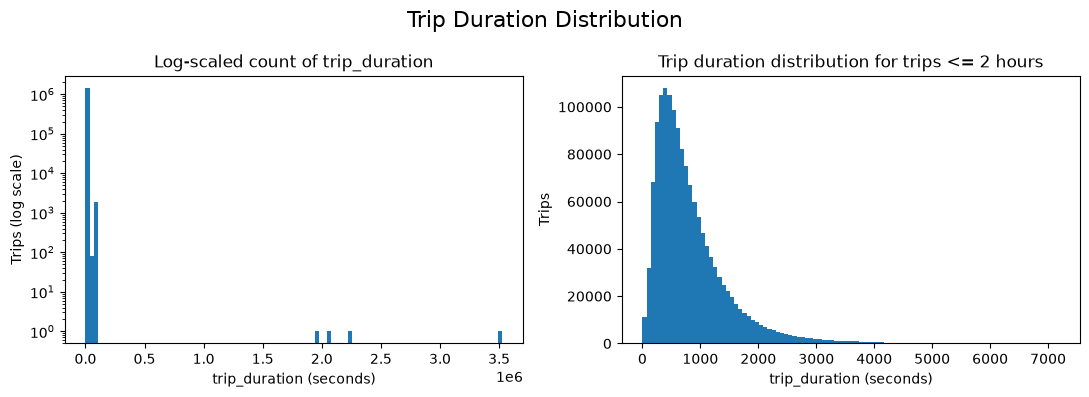

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].hist(df_taxi["trip_duration"], bins=100)
ax[0].set_yscale("log")
ax[0].set_title("Log-scaled count of trip_duration")
ax[0].set_xlabel("trip_duration (seconds)")
ax[0].set_ylabel("Trips (log scale)")

sub_2hrs = df_taxi.loc[df_taxi["trip_duration"] <= 7200, "trip_duration"]
ax[1].hist(sub_2hrs, bins=100)
ax[1].set_title("Trip duration distribution for trips <= 2 hours")
ax[1].set_xlabel("trip_duration (seconds)")
ax[1].set_ylabel("Trips")

fig.suptitle("Trip Duration Distribution", fontsize=16)
plt.tight_layout()
plt.show()

The distribution on the left is the overall trip duration distribution with the trip counts in the log scale. It is heavily right-skewed with most of its values on the lower values. There are longer durations and previously we have determined that it reached 979 hours!

The distribution on the right is the same distribution but we only show the trips <= 2hrs, and the trip count is in raw scale. It is still right-skewed.

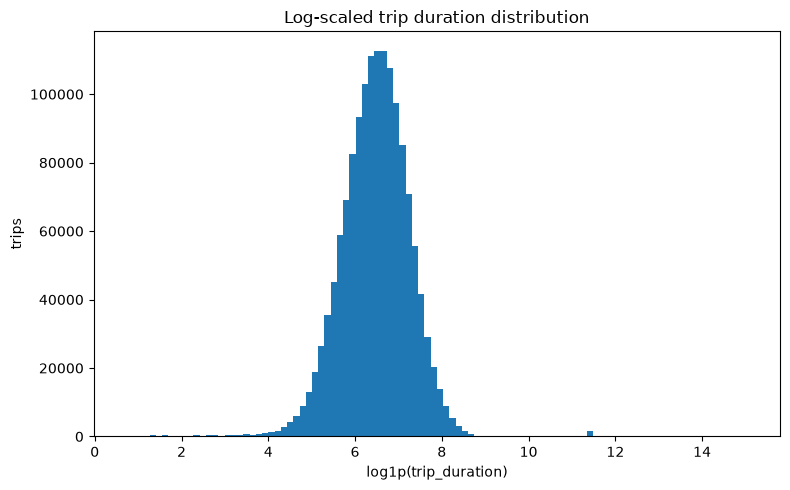

In [8]:
df_taxi['trip_duration_log'] = np.log1p(df_taxi['trip_duration'])

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df_taxi['trip_duration_log'], bins=100)
ax.set_title('Log-scaled trip duration distribution')
ax.set_xlabel("log1p(trip_duration)")
ax.set_ylabel("trips")
plt.tight_layout()
plt.show()

After converting the trip duration to logarithmic scale, it can be observed that the resulting distribution almost forms a symmetric distribution. It slightly resembles a normal distribution.

C:\Users\SCRUBBED 1796\AppData\Local\Temp\ipykernel_20684\2001691399.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df_taxi['trip_duration_log'], vert=False, patch_artist=True, boxprops=dict(facecolor='lightblue'))


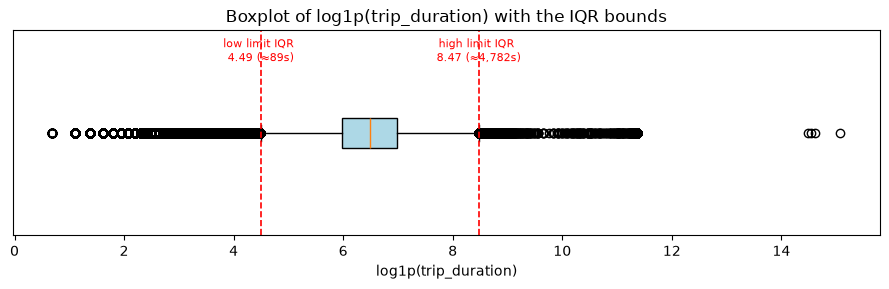

IQR limits for log-scaled trip duration:
Low limit: 4.495
High limit: 8.473


IQR limits equivalent in original scale:
Low limit: 89 seconds
High limit: 4782 seconds


In [9]:
# Checking for outliers through the IQR method, but we measure IQR on the log-scaled trip duration to avoid the influence of extreme values

Q1 = df_taxi['trip_duration_log'].quantile(0.25)
Q3 = df_taxi['trip_duration_log'].quantile(0.75)
IQR = Q3 - Q1

high_limit = Q3 + 1.5 * IQR
low_limit = Q1 - 1.5 * IQR

fig, ax = plt.subplots(figsize=(9, 3))
ax.boxplot(df_taxi['trip_duration_log'], vert=False, patch_artist=True, boxprops=dict(facecolor='lightblue'))
ax.axvline(low_limit, color='red', linestyle="--", linewidth=1.2)
ax.axvline(high_limit, color='red', linestyle="--", linewidth=1.2)
ax.annotate(f"low limit IQR \n{low_limit:.2f} (≈{np.expm1(low_limit):,.0f}s)",
                xy=(low_limit, 1.35), ha="center", fontsize=8, color='red')
ax.annotate(f"high limit IQR \n{high_limit:.2f} (≈{np.expm1(high_limit):,.0f}s)",
                xy=(high_limit, 1.35), ha="center", fontsize=8, color='red')
ax.set_yticks([])
ax.set_xlabel("log1p(trip_duration)")
ax.set_title("Boxplot of log1p(trip_duration) with the IQR bounds")

plt.tight_layout()
plt.show()

print('IQR limits for log-scaled trip duration:')
print(f'Low limit: {low_limit:.3f}')
print(f'High limit: {high_limit:.3f}')

print('\n')
print('IQR limits equivalent in original scale:')
print(f'Low limit: {np.expm1(low_limit):,.0f} seconds')
print(f'High limit: {np.expm1(high_limit):.0f} seconds')

The interquantile range method (IQR) is a standard method used to determine outliers in a dataset. It makes use of the 25th and 75th percentile.

The boxplot of the log-scaled trip duration shows that there are outliers outside the interquantile ranges. We will filter these out later. The IQR was calculated based on the log-scaled duration. The limits are [4.495, 8.473] which is [89 s, 4782 s] in the original scale.

### Identifying Anomalies

C:\Users\SCRUBBED 1796\AppData\Local\Temp\ipykernel_20684\1804711134.py:45: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\SCRUBBED 1796\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


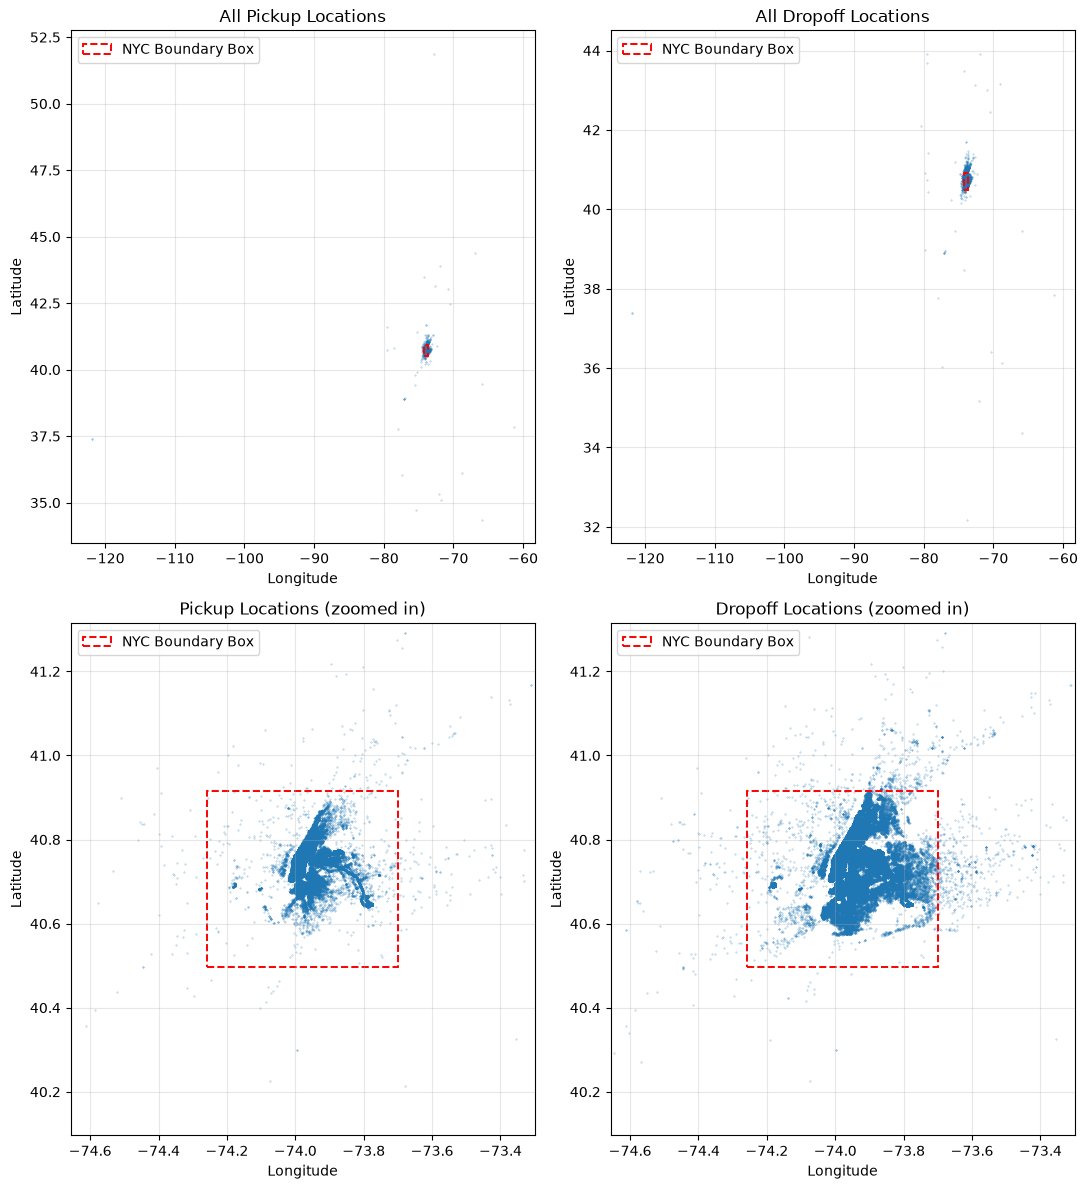

Trips with pickup or dropoff outside the NYC Bounding Box: 1,345


In [62]:
LAT_MIN, LAT_MAX = 40.496010, 40.915568   # NYC Bounding Box (taken from https://s-media.nyc.gov/agencies/dcp/assets/files/pdf/data-tools/bytes/nybb_metadata.pdf#:~:text=The%20official%20borough%20boundaries,*%20South%20latitude.)
LON_MIN, LON_MAX = -74.257159, -73.699215

fig, ax = plt.subplots(2,2,figsize=(11,12))
ax[0,0].scatter(df_taxi['pickup_longitude'], df_taxi['pickup_latitude'], s=0.1, alpha=0.5)
ax[0,0].add_patch(Rectangle((LON_MIN, LAT_MIN), LON_MAX - LON_MIN, LAT_MAX - LAT_MIN,
                           fill=False, edgecolor='red', linewidth=1.4, linestyle='--', label='NYC Boundary Box'))
ax[0,0].set_title('All Pickup Locations')
ax[0,0].set_xlabel('Longitude')
ax[0,0].set_ylabel('Latitude')
ax[0,0].legend()
ax[0,0].grid(alpha=0.3)

ax[0,1].scatter(df_taxi['dropoff_longitude'], df_taxi['dropoff_latitude'], s=0.1, alpha=0.5)
ax[0,1].add_patch(Rectangle((LON_MIN, LAT_MIN), LON_MAX - LON_MIN, LAT_MAX - LAT_MIN,
                           fill=False, edgecolor='red', linewidth=1.4, linestyle='--', label='NYC Boundary Box'))
ax[0,1].set_title('All Dropoff Locations')
ax[0,1].set_xlabel('Longitude')
ax[0,1].set_ylabel('Latitude')
ax[0,1].legend()
ax[0,1].grid(alpha=0.3)

ax[1,0].scatter(df_taxi['pickup_longitude'], df_taxi['pickup_latitude'], s=0.1, alpha=0.5)
ax[1,0].add_patch(Rectangle((LON_MIN, LAT_MIN), LON_MAX - LON_MIN, LAT_MAX - LAT_MIN,
                           fill=False, edgecolor='red', linewidth=1.4, linestyle='--', label='NYC Boundary Box'))
ax[1,0].set_title('Pickup Locations (zoomed in)')
ax[1,0].set_xlabel('Longitude')
ax[1,0].set_ylabel('Latitude')
ax[1,0].set_xlim(LON_MIN - 0.4, LON_MAX + 0.4)
ax[1,0].set_ylim(LAT_MIN - 0.4, LAT_MAX + 0.4)
ax[1,0].legend()
ax[1,0].grid(alpha=0.3)

ax[1,1].scatter(df_taxi['dropoff_longitude'], df_taxi['dropoff_latitude'], s=0.1, alpha=0.5)
ax[1,1].add_patch(Rectangle((LON_MIN, LAT_MIN), LON_MAX - LON_MIN, LAT_MAX - LAT_MIN,
                           fill=False, edgecolor='red', linewidth=1.4, linestyle='--', label='NYC Boundary Box'))
ax[1,1].set_title('Dropoff Locations (zoomed in)')
ax[1,1].set_xlabel('Longitude')
ax[1,1].set_ylabel('Latitude')
ax[1,1].set_xlim(LON_MIN - 0.4, LON_MAX + 0.4)
ax[1,1].set_ylim(LAT_MIN - 0.4, LAT_MAX + 0.4)
ax[1,1].legend()
ax[1,1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

out_nyc_box = ~(
    df_taxi["pickup_latitude"].between(LAT_MIN, LAT_MAX)
    & df_taxi["pickup_longitude"].between(LON_MIN, LON_MAX)
    & df_taxi["dropoff_latitude"].between(LAT_MIN, LAT_MAX)
    & df_taxi["dropoff_longitude"].between(LON_MIN, LON_MAX)
)
print(f"Trips with pickup or dropoff outside the NYC Bounding Box: {out_nyc_box.sum():,}")

The NYC boundary latitudes and longitudes were taken from an NYC document (https://s-media.nyc.gov/agencies/dcp/assets/files/pdf/data-tools/bytes/nybb_metadata.pdf#:~:text=The%20official%20borough%20boundaries,*%20South%20latitude.)

The figure above shows that there are pickup and dropoff locations located outside the NYC boundary box (denoted in red-dashed rectangle). There is a total of 1345 trips with pickup or dropoff locations outside the NYC boundary box.

The upper left and upper right photos show that the NYC boundary box is just a small area when comparing to the latitude and longitude range in the dataset.

When we zoom in to the pickup and dropoff locations, it can be visually observed that there are more dropoffs within NYC than the pickup itself. In this study, we only use the trips that have pickup AND dropoff within the NYC boundary box.

passenger_count
0         60
1    1033540
2     210318
3      59896
4      28404
5      78088
6      48333
7          3
8          1
9          1
Name: count, dtype: int64


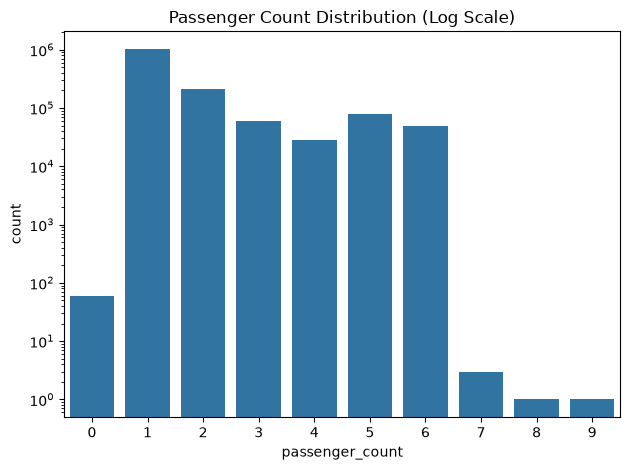

In [11]:
# Checking for passenger count values
print(df_taxi['passenger_count'].value_counts().sort_index())

sns.countplot(x='passenger_count', data=df_taxi)
plt.yscale('log')
plt.title('Passenger Count Distribution (Log Scale)')
plt.tight_layout()
plt.show()

The figure above shows the passenger count distribution. Notice how there are 60 trips with zero passenger count even though they are labeled as metered trips in the dataset. This can be removed later on. We can confidently remove these because they compromise a very small portion of the whole dataset (60 out of ~1.4 million)

The maximum number of passenger count in a single trip is 9. We can keep this in the dataset because it might include high passenger capacity vehicles that can be used as a metered taxi vehicle.

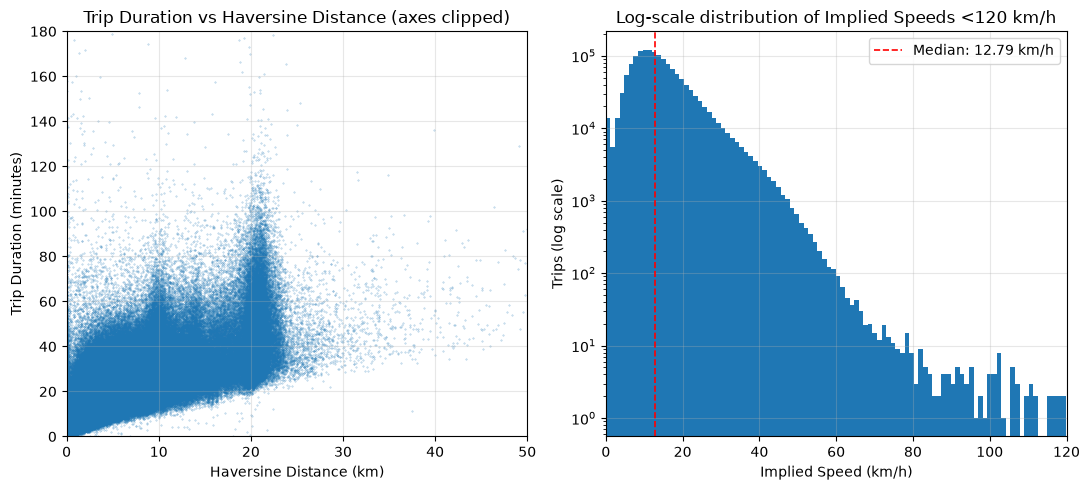

Anomalies with Implied Speed:
Number of trips with implied speed < 1 km/h: 13,240
Number of trips with implied speed > 120 km/h: 136
Near-zero distance (<0.05 km) but > 1 hour duration: 58


In [12]:
# Lets try comparing the haversine distance with the trip duration to see if there is a correlation between the two
implied_speed_kmh = df_taxi['haversine_distance'] / (df_taxi['trip_duration'] / (60*60))  

fig, ax = plt.subplots(1,2, figsize=(11, 5))
ax[0].scatter(df_taxi['haversine_distance'], df_taxi['trip_duration']/60.0, s=0.1, alpha=0.5)
ax[0].set_xlim(0, 50)
ax[0].set_ylim(0, 180)
ax[0].set_xlabel('Haversine Distance (km)')
ax[0].set_ylabel('Trip Duration (minutes)')
ax[0].set_title('Trip Duration vs Haversine Distance (axes clipped)')
ax[0].grid(alpha=0.3)

implied_speed_sub120 = implied_speed_kmh[implied_speed_kmh < 120]  # Filter out extreme speed estimates for better visualization
ax[1].hist(implied_speed_sub120 , bins=100)
ax[1].set_yscale('log')
ax[1].set_xlim(0, 120)
ax[1].axvline(implied_speed_sub120.median(), color='red', linestyle='--', linewidth=1.2, label=f'Median: {implied_speed_sub120.median():.2f} km/h')
ax[1].set_xlabel('Implied Speed (km/h)')
ax[1].set_ylabel('Trips (log scale)')
ax[1].set_title('Log-scale distribution of Implied Speeds <120 km/h')
ax[1].legend()
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('Anomalies with Implied Speed:')
very_slow_speed_count = (implied_speed_kmh < 1).sum()
very_high_speed_count = (implied_speed_kmh > 120).sum()
stucked = ((df_taxi["haversine_distance"] < 0.05) & (df_taxi["trip_duration"] > 3600)).sum()
print(f'Number of trips with implied speed < 1 km/h: {very_slow_speed_count:,}')
print(f'Number of trips with implied speed > 120 km/h: {very_high_speed_count:,}')
print(f"Near-zero distance (<0.05 km) but > 1 hour duration: {stucked:,}")

The scatter plot on the left shows the trip duration vs Haversine distance graph (x-axis is limited to 50 km). Majority of the trips have a Haversine distance of about 0-20 km. Around the 20 km mark, the trip duration varied a lot as indicated by the visible vertical formation pattern from ~20 minutes to ~120 minutes

The figure on the right shows the distribution of the implied speed (Haversine distance/trip duration). We only displayed trips that have implied speed less than 120 km/h. The median is 12.79 km/h, which means that half of the trips have implied speed less than or equal to 12.79 km/h.

There were anomalies detected such as 136 trips that are too fast, with implied speed of 120 km/h. There were also 58 trips that have near-zero distance (<0.05 km) but took more than 1 hour in duration.

### Temporal patterns

We check for temporal patterns in hour-of-day, and day-of-week. The median trip duration is used throughout since the data is skewed. Other metrics like the mean is unreliable.

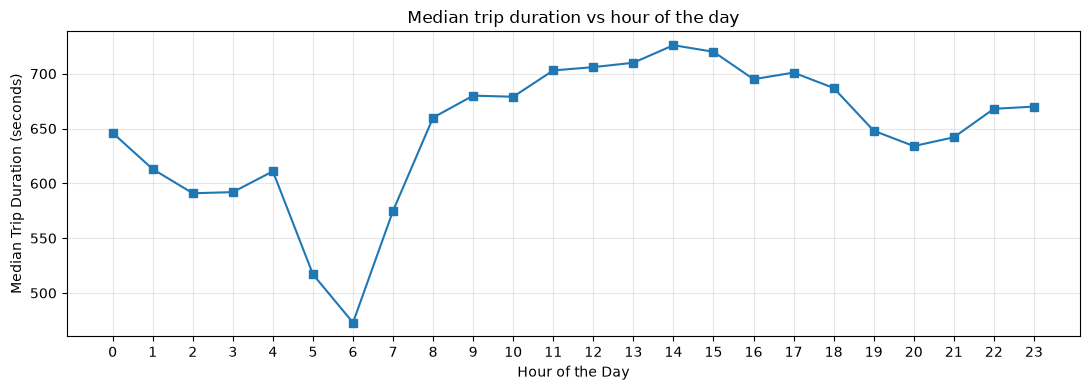

Median trip duration per hour of the day:
pickup_datetime
0     646.0
1     613.0
2     591.0
3     592.0
4     611.0
5     517.0
6     473.0
7     575.0
8     660.0
9     680.0
10    679.0
11    703.0
12    706.0
13    710.0
14    726.0
15    720.0
16    695.0
17    701.0
18    687.0
19    648.0
20    634.0
21    642.0
22    668.0
23    670.0
Name: trip_duration, dtype: float64
Lowest median trip duration hour: 6 with median duration of 473.0 seconds
Highest median trip duration hour: 14 with median duration of 726.0 seconds


In [13]:
# Checking if there are any patterns in trip duration based on the hour of the day
hour = df_taxi["pickup_datetime"].dt.hour
median_duration_per_hour = df_taxi.groupby(hour)["trip_duration"].median()

plt.figure(figsize=(11, 4))
plt.plot(median_duration_per_hour, marker='s')
plt.xlabel('Hour of the Day')
plt.ylabel('Median Trip Duration (seconds)')
plt.title('Median trip duration vs hour of the day')
plt.xticks(range(24))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('Median trip duration per hour of the day:')
print(median_duration_per_hour)
# print('\n')
print('Lowest median trip duration hour:', median_duration_per_hour.idxmin(), 'with median duration of', median_duration_per_hour.min(), 'seconds')
print('Highest median trip duration hour:', median_duration_per_hour.idxmax(), 'with median duration of', median_duration_per_hour.max(), 'seconds')

There's a pattern on the median trip duration throughout the hours of the day. It looks like it follows a cyclic pattern. The lowest median trip duration is during 6 AM, followed by 5 AM, then 7 AM. The longest median trip duration occurs during 2 PM. The median trip duration is high during 11 AM until 6 PM.

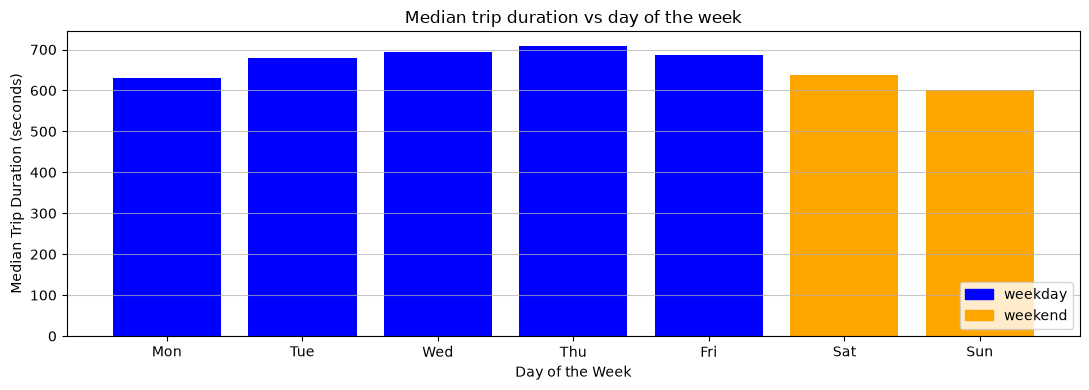

Median trip duration per day of the week:
Mon: 630.0 seconds
Tue: 679.0 seconds
Wed: 694.0 seconds
Thu: 709.0 seconds
Fri: 686.0 seconds
Sat: 637.0 seconds
Sun: 602.0 seconds


Median trip duration on weekdays: 679.6 seconds
Median trip duration on weekends: 619.5 seconds


In [14]:
# Checking for patterns in trip duration based on the day of the week
day_of_week = df_taxi["pickup_datetime"].dt.dayofweek
median_duration_per_day = df_taxi.groupby(day_of_week)["trip_duration"].median()
day_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
colors = ['blue', 'blue', 'blue', 'blue', 'blue', 'orange', 'orange']  # Weekdays in blue, weekends in orange

plt.figure(figsize=(11, 4))
plt.bar(range(7), median_duration_per_day.values, color=colors)
plt.xlabel('Day of the Week')
plt.ylabel('Median Trip Duration (seconds)')
plt.title('Median trip duration vs day of the week')
plt.xticks(range(7), day_names)
plt.grid(alpha=0.7, axis='y')
plt.legend(handles=[plt.Rectangle((0,0),1,1, color='blue'), plt.Rectangle((0,0),1,1, color='orange')], labels=['weekday', 'weekend'], loc='lower right')
plt.tight_layout()
plt.show()

print('Median trip duration per day of the week:')
for i, day in enumerate(day_names):
    print(f'{day}: {median_duration_per_day[i]} seconds')

print('\n')
print('Median trip duration on weekdays:', median_duration_per_day[:5].mean(), 'seconds')
print('Median trip duration on weekends:', median_duration_per_day[5:].mean(), 'seconds')

Median trip duration during the weekdays are generally higher on weekdays (679 seconds) than weekends (619 seconds). The highest median through all days of the week is on Thursday (709 seconds), while the lowest falls on Sunday (602 seconds)

### Comparing categorical variables

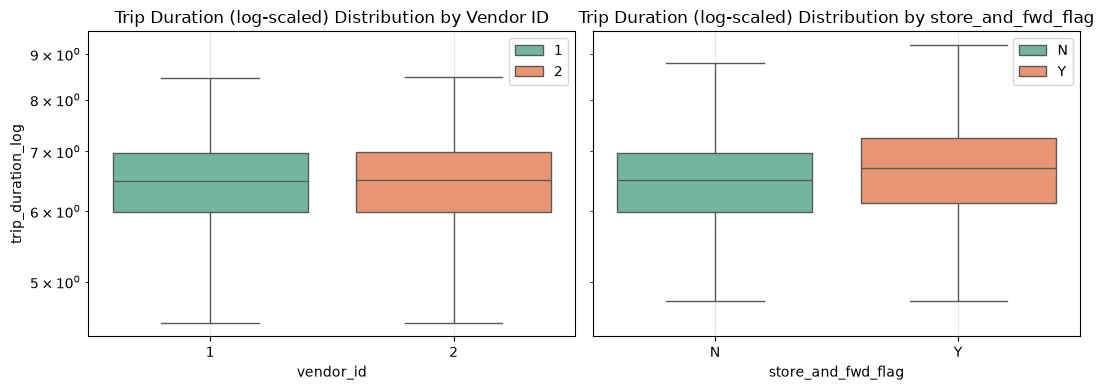

In [15]:
# Categorical comparisons for vendor_id and store_and_fwd_flag
fig, ax = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
sns.boxplot(x='vendor_id', y='trip_duration_log', data=df_taxi, hue='vendor_id', ax=ax[0], showfliers=False, palette='Set2')
ax[0].set_yscale('log')
ax[0].grid(alpha=0.3)
ax[0].legend()
ax[0].set_title('Trip Duration (log-scaled) Distribution by Vendor ID')
sns.boxplot(x='store_and_fwd_flag', y='trip_duration_log', data=df_taxi, hue='store_and_fwd_flag', ax=ax[1], showfliers=False, palette='Set2')
ax[1].set_yscale('log')
ax[1].grid(alpha=0.3)
ax[1].legend(labels=['N', 'Y'])
ax[1].set_title('Trip Duration (log-scaled) Distribution by store_and_fwd_flag')

plt.tight_layout()
plt.show()

The categorical columns barely shift the distribution. Note that the two boxplots share the same y-axis, both are in log-scaled trip duration. The distribution between the two vendors are identical. However, the store_and_fwd_flag distributions differ slightly. Based from the categorical field boxplots, we can say that they may have little effect to the trip duration.

### Data cleaning/filtering

We implement 3 data filters:
1. Drop trips that have zero passenger count. This is implausible for a metered taxi trip.
2. Filter out trips that have either pickup or dropoff location found outside the NYC boundary box (lat 40.496010°–40.915568° N, lon -74.257159°–(-73.699215° W))
3. Compute the log-scale IQR bounds on `trip_duration`. Drop the rows that are outside them.

The order matters. We computed the IQR bounds after the surviving data in 1 and 2.

In [16]:
# Applying filters to the dataset. We are filtering out 
# zero passenger count, 
# trips with coordinates outside the NYC boundary box (either pickup or dropoff outside NYC), 
# and trips with trip duration outside the IQR bounds (log-scaled).

n_raw = df_taxi.shape[0]

filter1 = df_taxi[df_taxi['passenger_count'] > 0]

within_nyc_box = (
    filter1["pickup_latitude"].between(LAT_MIN, LAT_MAX)
    & filter1["pickup_longitude"].between(LON_MIN, LON_MAX)
    & filter1["dropoff_latitude"].between(LAT_MIN, LAT_MAX)
    & filter1["dropoff_longitude"].between(LON_MIN, LON_MAX)
)
filter2 = filter1[within_nyc_box]

log_duration2 = np.log1p(filter2['trip_duration'])
Q1 = log_duration2.quantile(0.25)
Q3 = log_duration2.quantile(0.75)
IQR = Q3 - Q1
low_limit_log = Q1 - 1.5 * IQR
high_limit_log = Q3 + 1.5 * IQR

clean_df = filter2[(log_duration2 >= low_limit_log) & (log_duration2 <= high_limit_log)].copy()

print(f"Before filtering:                  {n_raw:>9,}")
print(f"1. passenger_count >= 1:           {len(filter1):>9,}  (-{n_raw - len(filter1):,})")
print(f"2. inside NYC Bounding Box:        {len(filter2):>9,}  (-{len(filter1) - len(filter2):,})")
print(f"3. log-scale IQR on trip_duration: {len(clean_df):>9,}  (-{len(filter2) - len(clean_df):,})")
print(f"\nIQR bounds: [{np.expm1(low_limit_log):,.1f}s, {np.expm1(high_limit_log):,.1f}s] "
      f"(log space: [{low_limit_log:.3f}, {high_limit_log:.3f}])")
print(f"Valid Trips retained: {len(clean_df) / n_raw:.1%} of raw data")

Before filtering:                  1,458,644
1. passenger_count >= 1:           1,458,584  (-60)
2. inside NYC Bounding Box:        1,457,239  (-1,345)
3. log-scale IQR on trip_duration: 1,438,054  (-19,185)

IQR bounds: [88.7s, 4,771.0s] (log space: [4.496, 8.471])
Valid Trips retained: 98.6% of raw data


After data cleaning and filtering, we are left with ~1.4 million rows of data.

# Feature Engineering

This section contains the clean and final Feature Matrix which will be used to train the models.

In [17]:
fe_clean_df = clean_df.copy()
fe_clean_df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,trip_duration_calculated,is_correct_duration,haversine_distance,trip_duration_log
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455,455.0,True,1.498521,6.122493
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663,663.0,True,1.805507,6.498282
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124,2124.0,True,6.385098,7.661527
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429,429.0,True,1.485498,6.063785
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435,435.0,True,1.188588,6.077642


In [18]:
fe_clean_df['hour'] = fe_clean_df['pickup_datetime'].dt.hour
fe_clean_df['day_of_week'] = fe_clean_df['pickup_datetime'].dt.dayofweek
fe_clean_df['is_weekend'] = fe_clean_df['day_of_week'].isin([5, 6]).astype(int)  # 1 for weekend, 0 for weekday

ohe = pd.get_dummies(fe_clean_df[['vendor_id', 'store_and_fwd_flag', 'hour', 'day_of_week']].astype('category')
                     , drop_first=True, dtype=int
)
X = pd.concat([fe_clean_df[['passenger_count', 'haversine_distance', 'is_weekend']], ohe], axis=1)
y = fe_clean_df['trip_duration_log']

print(f"Feature Matrix: {X.shape[0]:,} Valid Trips x {X.shape[1]} features")
print(X.columns)


Feature Matrix: 1,438,054 Valid Trips x 34 features
Index(['passenger_count', 'haversine_distance', 'is_weekend', 'vendor_id_2',
       'store_and_fwd_flag_Y', 'hour_1', 'hour_2', 'hour_3', 'hour_4',
       'hour_5', 'hour_6', 'hour_7', 'hour_8', 'hour_9', 'hour_10', 'hour_11',
       'hour_12', 'hour_13', 'hour_14', 'hour_15', 'hour_16', 'hour_17',
       'hour_18', 'hour_19', 'hour_20', 'hour_21', 'hour_22', 'hour_23',
       'day_of_week_1', 'day_of_week_2', 'day_of_week_3', 'day_of_week_4',
       'day_of_week_5', 'day_of_week_6'],
      dtype='str')


The hour of day was extracted into the `hour` column. The day of the week was also extracte into the `day_of_week` column. A weekend flag was also added using the `is_weekend` column (1 for weekend, 0 for weekday).

We then proceeded to one-hot encode categorical variables `vendor_id` and `store_and_fwd_flag`. The `hour` and `day_of_week` column was also one-hot encoded for the benefit of the Linear Regression model. We do not want it to think that hour-23 is "greater" than hour-0 or day-6 is "greater" than day-1. Although Random forest does not this to be one-hot encoded, we still use the same feature matrix on training all the models for consistency.

Our final feature matrix has the following shape: 1,438,054 rows x 34 features

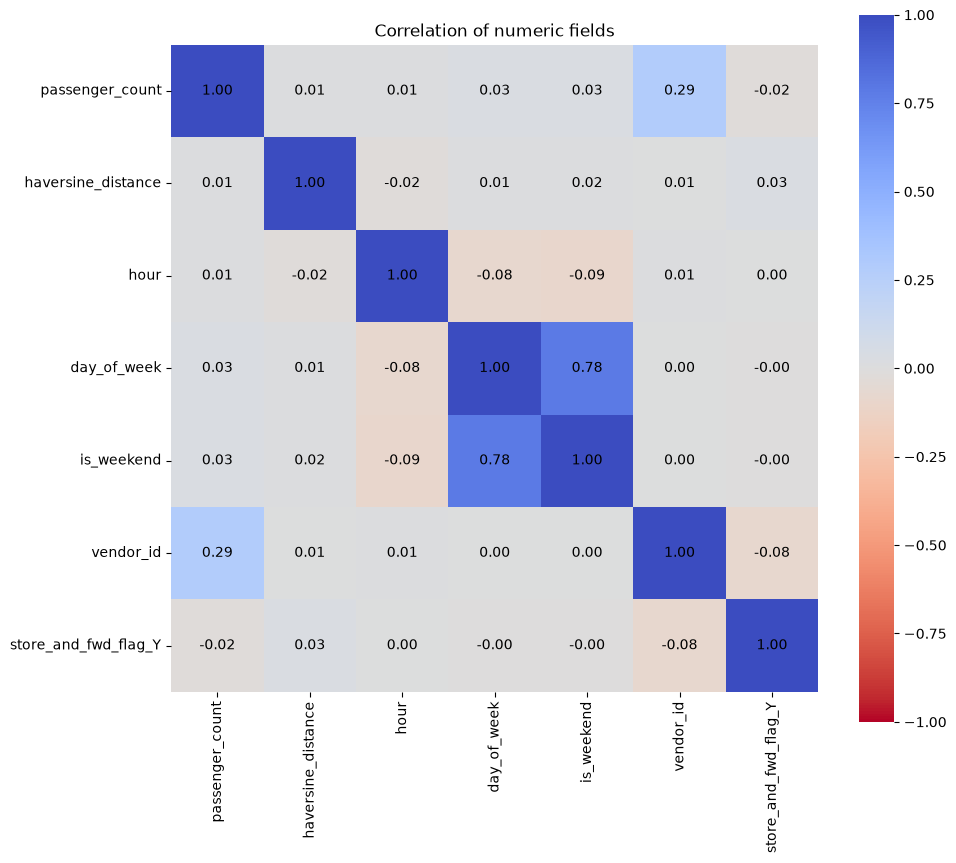

In [21]:
# Correlation heatmap of engineered feature matrix
corr = pd.concat([fe_clean_df[[
       'passenger_count',
       'haversine_distance', 'hour', 'day_of_week',
       'is_weekend', 'vendor_id']]
       ,ohe['store_and_fwd_flag_Y']],axis=1).corr()

fig, ax = plt.subplots(figsize=(10,10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm_r', vmin=-1, vmax=1, square=True,
            annot_kws={"color": 'black'}, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Correlation of numeric fields")
plt.tight_layout()
plt.show()

# Model training and evaluation

This section contains model training and evaluation. Models used in this study were Linear Regression, Random Forest Regressor, and XGBoost Regressor. The models were compared to each other using root mean squared logarithmic error (RMSLE). RMSLE was used because it is the evaluation method used for all submissions in the Kaggle dataset.

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_log_error
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_squared_error
import time

SEED = 100

We put a random seed for reproducibility.

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=SEED)
print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")

Train: 1,078,540 | Test: 359,514


We implemented a 75/25 random train test split 

* Train dataset: 1,078,540 
* Test datset: 359,514

In [24]:
models = {
    "LinearRegression": LinearRegression(),
    "RandomForestRegressor": RandomForestRegressor(
        n_estimators=100, 
        max_depth=14,
        n_jobs=-1, 
        min_samples_leaf=20,
        random_state=SEED,
        ),
    "XGBRegressor": XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method='hist',
        n_jobs=-1,
        random_state=SEED
        )
}

preds, rows = {}, []
for name, model in models.items():
    t0 = time.perf_counter()
    model.fit(X_train, y_train)
    fit_s = time.perf_counter() - t0
    preds[name] = model.predict(X_test)
    rmsle = float(root_mean_squared_log_error(y_test, preds[name]))
    rows.append({"model": name, "RMSLE": rmsle, "fit_seconds": round(fit_s, 1)})
    print(f"{name:<18} RMSLE = {rmsle:.4f}  (fit {fit_s:,.1f}s)")

results = pd.DataFrame(rows).set_index("model")
results

LinearRegression   RMSLE = 0.0705  (fit 1.8s)
RandomForestRegressor RMSLE = 0.0553  (fit 246.9s)
XGBRegressor       RMSLE = 0.0539  (fit 11.8s)


,RMSLE,fit_seconds
model,,
LinearRegression,0.070482,1.8
RandomForestRegressor,0.055300,246.9
XGBRegressor,0.053949,11.8


The training time of the Linear regression took 1.8 seconds. It is the shortest among the three models. The Random Forest took the longest to train at ~246 seconds. The XGBoost model only took 11.8 seconds to train, while also having the least RMSLE among the three. 

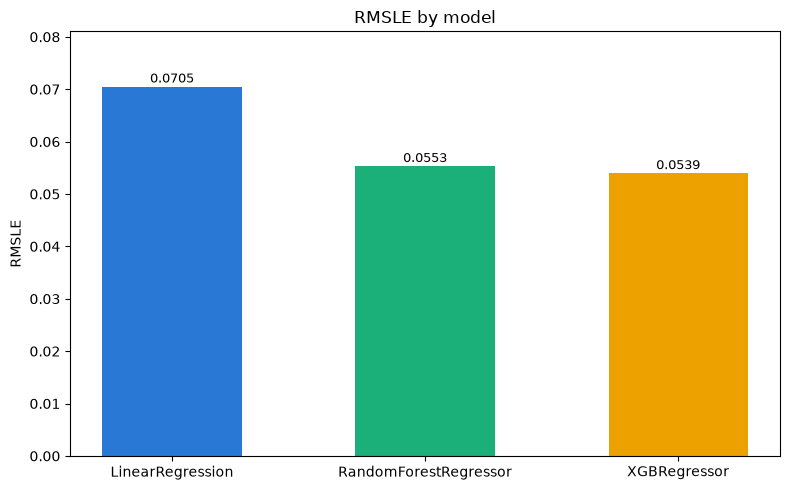

In [26]:
MODEL_COLORS = {"LinearRegression": '#2a78d6', "RandomForestRegressor": '#1baf7a', "XGBRegressor": '#eda100'}

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(results.index, results["RMSLE"],
              color=[MODEL_COLORS[m] for m in results.index],
             width=0.55)
for bar, v in zip(bars, results["RMSLE"]):
    ax.annotate(f"{v:.4f}", xy=(bar.get_x() + bar.get_width() / 2, v),
                xytext=(0, 3), textcoords="offset points",
                ha="center", fontsize=9, color='black')
ax.set_ylim(0, results["RMSLE"].max() * 1.15)
ax.set_title("RMSLE by model")
ax.set_ylabel("RMSLE")
plt.tight_layout()
plt.show()

The XGBRegressor is the best performing model in terms of RMSLE. It has the lowest RMSLE but it has a similar score with Random Forest. Although the Random Forest is comparable with XGBRegressor, it took approximately ~246 seconds to train compared to XGBRegressor's 11.8 seconds. This makes XGBRegressor ~20 times faster than the 2nd best performing model (Random Forest).

The linear regression model performed the least among the three models, while taking the least time to train. This is expected because linear regression is the baseline model used in this study. It is also possible that there are nonlinear behaviors in the dataset that the linear regression model failed to capture.

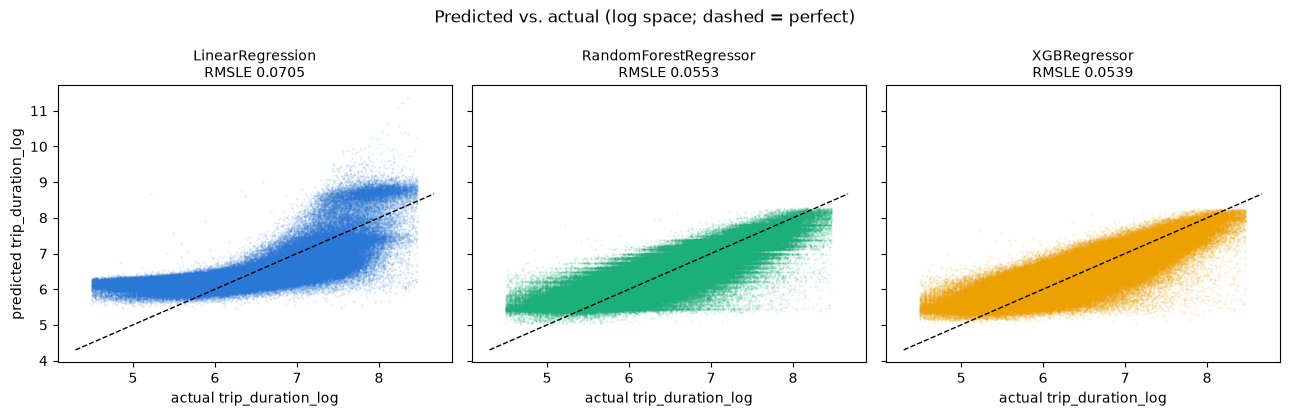

In [ ]:
# rng = np.random.default_rng(SEED)
# idx = rng.choice(len(y_test), size=20_000, replace=False)
# y_test_s = y_test.to_numpy()[idx]

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), sharex=True, sharey=True)
lims = (y_test.min() - 0.2, y_test.max() + 0.2)
for ax, (name, prediction) in zip(axes, preds.items()):
    ax.scatter(y_test, prediction, s=2, alpha=0.15, color=MODEL_COLORS[name], linewidths=0)
    ax.plot(lims, lims, color='black', linewidth=1, linestyle="--")
    ax.set_title(f"{name}\nRMSLE {results.loc[name, 'RMSLE']:.4f}", fontsize=10)
    ax.set_xlabel("actual trip_duration_log")
axes[0].set_ylabel("predicted trip_duration_log")
fig.suptitle("Predicted vs. actual (log space; dashed = perfect)")
plt.tight_layout()
plt.show()

The figure above shows the predicted vs actual `trip_duration_log`. The dashed line represents a perfect model where all predicted = actual.

We can see that the Random Forest and XGBRegressor values stay close to the dashed line. We can also see that the values from Linear regression scatter more than the other models around the dashed line. This is expected because the Random Forest and XGBRegressor performed significantly better than Linear Regression.

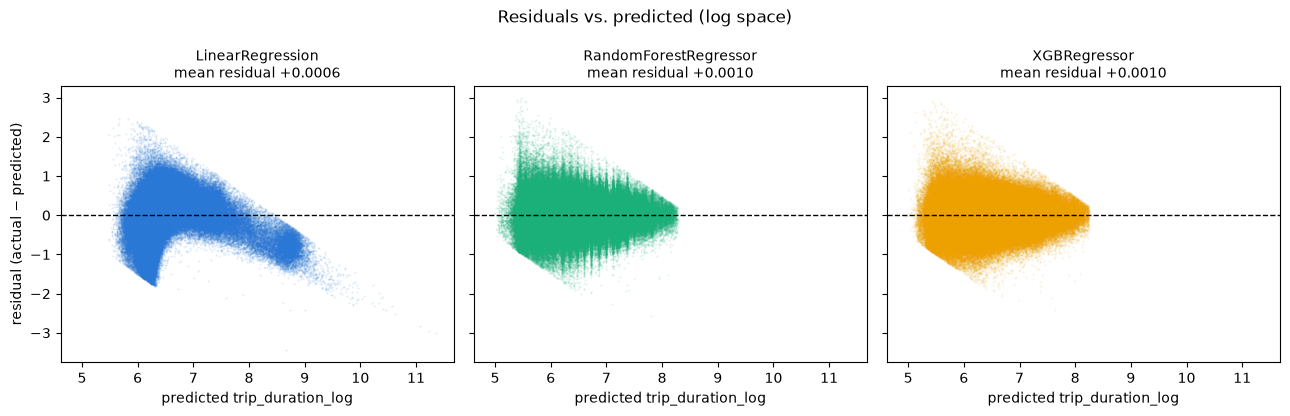

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), sharex=True, sharey=True)
for ax, (name, prediction) in zip(axes, preds.items()):
    residuals = y_test - prediction
    ax.scatter(prediction, residuals, s=2, alpha=0.15, color=MODEL_COLORS[name], linewidths=0)
    ax.axhline(0, color='black', linewidth=1, linestyle="--")
    ax.set_title(f"{name}\nmean residual {float(np.mean(y_test.to_numpy() - prediction)):+.4f}", fontsize=10)
    ax.set_xlabel("predicted trip_duration_log")
axes[0].set_ylabel("residual (actual − predicted)")
fig.suptitle("Residuals vs. predicted (log space)")
plt.tight_layout()
plt.show()

The figure above shows the residuals vs predicted values. Residuals refer to actual - predicted values. The dashed line represents zero residual. A perfect model will have zero residuals (actual = predicted).

The residual plot for Random Forest and XGBRegressor are visibly similar and located near the center. They have the same mean residuals of +0.0010. The residual plot of linear regression visibly differs from the other two models. It forms a distinct curve with an opening towards the bottom. It compresses most predictions into a narrow band and underpredicts long trips.

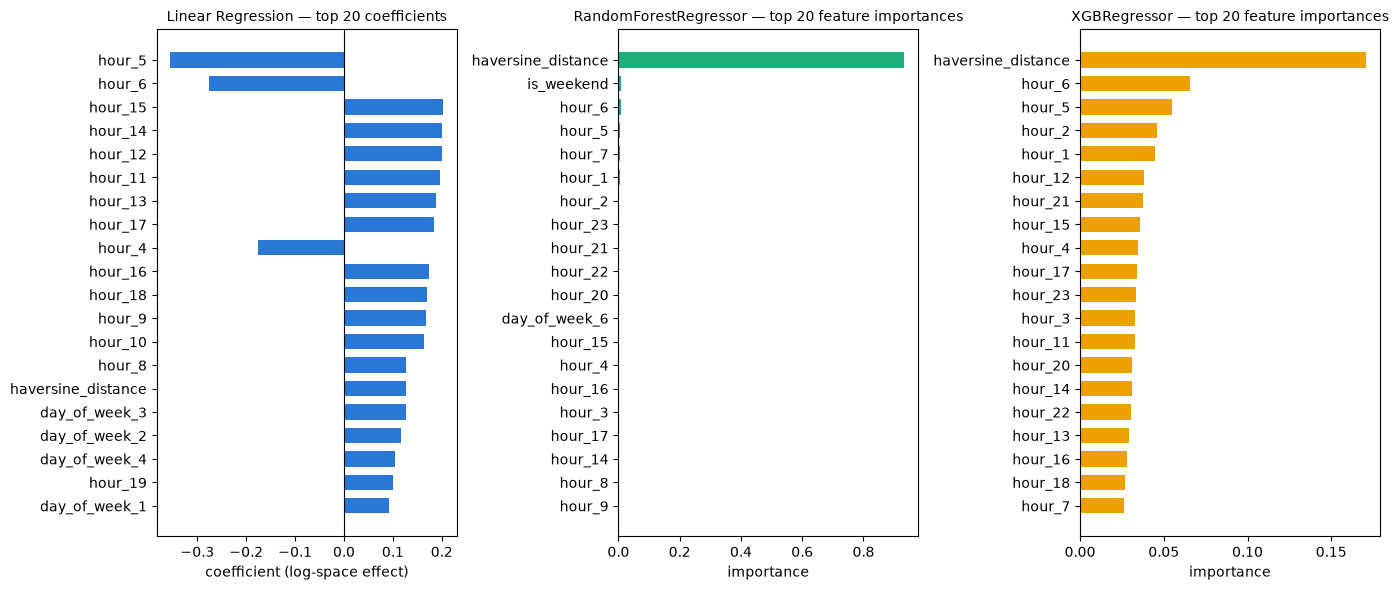

In [61]:
TOP_N = 20

fig, axes = plt.subplots(1, 3, figsize=(14, 6))

lr_coefs = pd.Series(models["LinearRegression"].coef_, index=X.columns)
top_lr = lr_coefs.reindex(lr_coefs.abs().sort_values(ascending=False).head(TOP_N).index)[::-1]
axes[0].barh(top_lr.index, top_lr.values, color=MODEL_COLORS["LinearRegression"], height=0.65)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title(f"Linear Regression — top {TOP_N} coefficients",
                  fontsize=10)
axes[0].set_xlabel("coefficient (log-space effect)")

for ax, name in zip(axes[1:], ["RandomForestRegressor", "XGBRegressor"]):
    imp = pd.Series(models[name].feature_importances_, index=X.columns)
    top = imp.sort_values(ascending=False).head(TOP_N)[::-1]
    ax.barh(top.index, top.values, color=MODEL_COLORS[name], height=0.65)
    ax.set_title(f"{name} — top {TOP_N} feature importances", fontsize=10)
    ax.set_xlabel("importance")

plt.tight_layout()
plt.show()

For linear regression, the 2 highest magnitude coefficients are `hour_5` and `hour_6`, and they are negative. This is expected because it is during 5 AM and 6 AM that the least median trip duration occurs. The next top coefficients are positive which represent noon-afternoon hours which is also expected because higher median trip duration occur at these hours. `haversine_distance` is far back in the top 15. This suggests that it may have nonlinear behaviors that the linear regression model failed to capture. Results also suggest the hours of the day matter more than days of the week in predicting trip duration.

For Random Forest Regressor, the `haversine_distance` has the highest importance among all other features (~0.93). This confirms our hunch that it has nonlinear behaviors. A random forest model has no difficulty in detecting nonlinear effects. The 2nd highest important feature is `is_weekend`. This was followed by `hour_6` and `hour_5`, which is also expected based from our EDA.

For XGBRegressor, `haversine_distance` also has the highest importance (~0.17). This was followed by `hour_6` and `hour_5`, which we now observed to be a key factor in predicting trip duration in this study. All succeeding top important features came from `hour` of the day features.

The three models share a theme that hour of the day matters more than the day of the week in predicting trip duration. There is an exception in Random Forest where `is_weekend` is the 2nd most important feature. In the tree models, the most important feature is `haversine_distance` while it is only top 15 in the linear regression model.

# Conclusions



Model comparison (RMSLE on the 25% test split, Train: 1078540 | Test: 359514, 34 features):

| Model | RMSLE |
|---|---|
| **XGBoost** | **0.0539** |
| Random Forest | 0.0553 |
| Linear Regression | 0.0705 |


**XGBoost is the overall best model**. Random Forest is the second best with comparable RMSLE. The significant gap to Linear Regression shows that the distance vs trip duration relationship is nonlinear. It also interacts with the hour of the day. The residual plot makes this visible: Linear Regression's residuals curve systematically, while both tree models' residuals are centered have no distinct shape.

**What are the key factors in the predictions?** `haversine_distance` is the most important feature in Random Forest (~0.93) and XGBoost (~0.17). The hour-of-day dummies are the second best driving factors. This is consistent with the EDA, where median duration by pickup hour  is lowest in early-mornings and peaks during noon-afternoon. `passenger_count`, `vendor_id`, and `store_and_fwd_flag` had little to no effect on the trip duration.

In future studies, it is recommended to perform hyperparameter tuning to further enhance the XGBoost model.